In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [190]:
df = pd.read_csv("./train1.csv", usecols=["Survived","Age","Fare"])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [191]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [192]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [193]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [194]:
X_train["Age_Imputed"] = X_train["Age"]
X_test["Age_Imputed"] = X_test["Age"]

In [195]:
X_train.sample(5)

,Age,Fare,Age_Imputed
289,22.0,7.7500,22.0
736,48.0,34.3750,48.0
513,54.0,59.4000,54.0
759,33.0,86.5000,33.0
36,NaN,7.2292,NaN


In [196]:
X_train.loc[X_train["Age_Imputed"].isnull(), "Age_Imputed"] = X_train["Age"].dropna().sample(X_train["Age"].isnull().sum(), random_state=42).values
X_test.loc[X_test["Age_Imputed"].isnull(), "Age_Imputed"] = X_train["Age"].dropna().sample(X_test["Age"].isnull().sum(), random_state=42).values

In [197]:
X_train["Age"].dropna().sample(X_train["Age"].isnull().sum()).values

array([21.  ,  3.  , 29.  ,  2.  , 40.  , 30.  , 40.  , 27.  , 32.  ,
       22.  , 16.  , 60.  , 25.  , 18.  , 50.  , 45.  , 22.  , 19.  ,
        0.75, 18.  , 36.  , 18.  , 30.  , 23.  , 33.  , 19.  , 26.  ,
       37.  , 70.5 , 49.  , 33.  , 24.  , 60.  , 25.  , 20.  , 47.  ,
       32.  , 45.  , 28.  , 28.  , 14.5 , 45.  , 56.  , 41.  ,  9.  ,
       42.  ,  8.  , 58.  , 30.  ,  2.  , 22.  , 23.  , 38.  , 11.  ,
       18.  , 32.  , 25.  ,  0.75, 49.  , 34.  , 44.  ,  9.  , 33.  ,
       58.  , 45.  , 28.  , 22.  ,  3.  ,  2.  , 62.  , 24.  , 24.  ,
       33.  , 29.  , 45.  , 16.  ,  8.  , 34.  , 24.  , 22.  , 21.  ,
       31.  , 20.  , 43.  , 63.  , 35.  , 47.  , 24.  , 23.  , 56.  ,
       47.  , 14.  , 31.  , 18.  , 20.  , 23.  , 29.  , 16.  , 44.  ,
       27.  , 36.  , 36.  , 23.  , 41.  , 41.  , 19.  , 54.  , 49.  ,
       22.  , 49.  , 56.  , 61.  ,  4.  , 25.  , 42.  , 24.  , 22.  ,
       47.  , 30.  , 30.  , 14.  , 33.  , 13.  , 24.  , 57.  , 17.  ,
       37.  , 18.  ,

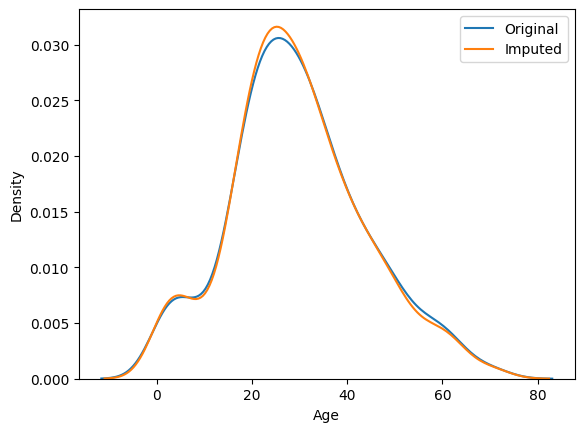

In [198]:
sns.kdeplot(X_train["Age"], label="Original")
sns.kdeplot(X_train["Age_Imputed"], label="Imputed")

plt.legend()
plt.show()

In [199]:
print("Original Variance", df["Age"].var())
print("Variance after random imputation", X_train["Age_Imputed"].var())

Original Variance 211.01912474630802
Variance after random imputation 200.02896637747122


In [200]:
X_train[['Fare', 'Age', 'Age_Imputed']].cov()

,Fare,Age,Age_Imputed
Fare,2368.246832,71.512440,53.259863
Age,71.512440,204.349513,204.349513
Age_Imputed,53.259863,204.349513,200.028966


<Axes: >

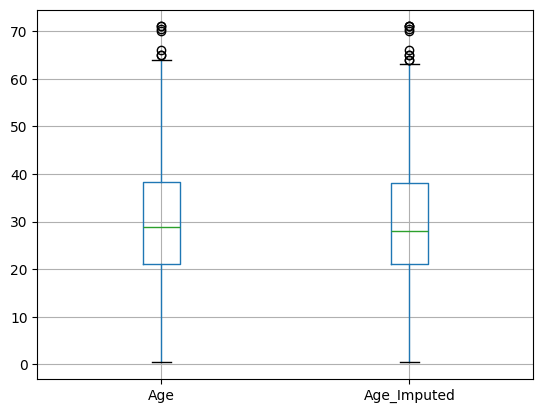

In [201]:
X_train[['Age', 'Age_Imputed']].boxplot()

In [202]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [203]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [204]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [205]:
X = data
y = data["SalePrice"]

In [206]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [207]:
X_train["GarageQual_Imputed"] = X_train["GarageQual"]
X_test["GarageQual_Imputed"] = X_test["GarageQual"]

X_train["FireplaceQu_Imputed"] = X_train["FireplaceQu"]
X_test["FireplaceQu_Imputed"] = X_test["FireplaceQu"]

In [208]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_Imputed,FireplaceQu_Imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [209]:
X_train.loc[X_train["FireplaceQu_Imputed"].isnull(), "FireplaceQu_Imputed"] = X_train["FireplaceQu"].dropna().sample(X_train["FireplaceQu"].isnull().sum(), random_state=42).values
X_test.loc[X_test["FireplaceQu_Imputed"].isnull(), "FireplaceQu_Imputed"] = X_train["FireplaceQu"].dropna().sample(X_test["FireplaceQu"].isnull().sum(), random_state=42).values

In [211]:
temp = pd.concat(
    [
        X_train["FireplaceQu"].value_counts() / len(X_train["FireplaceQu"].dropna()),
        X_train["FireplaceQu_Imputed"].value_counts() / len(X_train)
    ],
    axis=1
)

temp.columns = ["Oroginal", "Imputed"]

temp

,Oroginal,Imputed
Gd,0.494272,0.500000
TA,0.412439,0.406678
Fa,0.040917,0.040240
Po,0.027823,0.028253
Ex,0.024550,0.024829


In [212]:
temp = pd.concat(
    [
        X_train["GarageQual"].value_counts() / len(X_train["GarageQual"].dropna()),
        X_train["GarageQual_Imputed"].value_counts() / len(X_train)
    ],
    axis=1
)

temp.columns = ["Oroginal", "Imputed"]

temp

,Oroginal,Imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


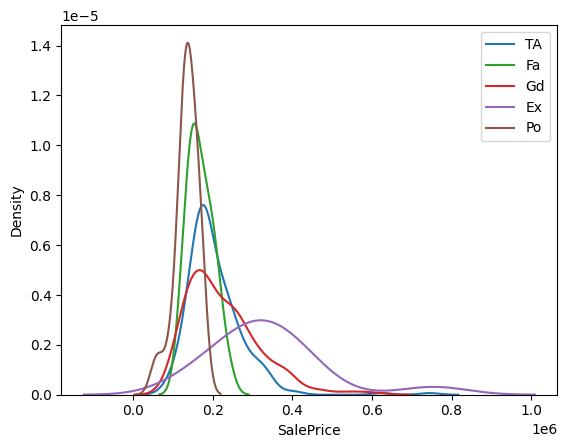

In [215]:
for cat in X_train["FireplaceQu"].unique():
    sns.kdeplot(X_train[X_train["FireplaceQu"] == cat]["SalePrice"], label = cat)
plt.legend()
plt.show()

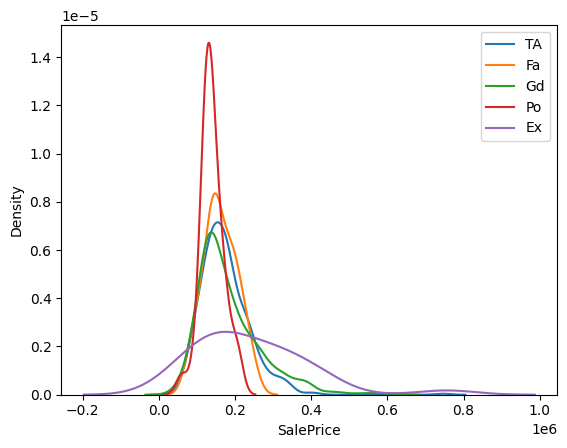

In [216]:
for cat in X_train["FireplaceQu_Imputed"].unique():
    sns.kdeplot(X_train[X_train["FireplaceQu_Imputed"] == cat]["SalePrice"], label = cat)
plt.legend()
plt.show()